In [108]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates


from Hawkes_functions import (
    DHP,
    CHP, CHP_plot, CHP_IC, CHP_IC_plot,
    neg_log_likelihood, hawkes_residuals,
    neg_log_likelihood_bivariate, hawkes_residuals_bivariate,
    spectral_det, trace_1, trace_2,
    engle_russell_ed_test, _default_bivariate_bounds,
    fit_univariate, univariate_goodness_of_fit, pass_rate_univariate,
    simulate_bivariate, fit_bivariate, bivariate_goodness_of_fit,
    pass_rate_bivariate_sim,pass_rate_windows
)

ImportError: cannot import name 'pass_rate_bivariate_sim' from 'Hawkes_functions' (/home/onyxia/work/Spread_Crypto/BTC_Fitting/Hawkes_functions.py)

In [44]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.optimize import brentq
from scipy.optimize import minimize, NonlinearConstraint
from scipy.stats import norm

from scipy.stats import kstest, expon
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch

from tick.hawkes import SimuHawkesExpKernels

In [3]:
import pandas as pd

chemin_fichier = "/home/onyxia/work/binance_data_10_09/BTCUSDT.csv.gz"

df_quotes = pd.read_csv(chemin_fichier)

# conversion in Datetime (unit = microsecondes)
df_quotes['datetime'] = pd.to_datetime(df_quotes['timestamp'], unit='us')

# mid-price
df_quotes['mid_price'] = (df_quotes['ask_price'] + df_quotes['bid_price']) / 2

# We only keep when prices actually move
df_jump_price = df_quotes[df_quotes['mid_price'] != df_quotes['mid_price'].shift(1)]

print(f"Total number of updates of the order book : {len(df_quotes)}")
print(f"Total number of updates in mid-prices : {len(df_jump_price)}")

Total number of updates of the order book : 600685
Total number of updates in mid-prices : 30404


In [4]:
df_jump_price.head()

,exchange,symbol,timestamp,local_timestamp,ask_amount,ask_price,bid_price,bid_amount,datetime,mid_price
0,binance,BTCUSDT,1788220801879719,1788220801879719,1.65496,78581.30,78581.29,0.27182,2026-09-01 00:00:01.879719,78581.295
84,binance,BTCUSDT,1788220813714468,1788220813716465,3.62306,78576.01,78576.00,0.27095,2026-09-01 00:00:13.714468,78576.005
139,binance,BTCUSDT,1788220822214299,1788220822215633,4.16015,78574.44,78574.43,0.54606,2026-09-01 00:00:22.214299,78574.435
147,binance,BTCUSDT,1788220823114370,1788220823117464,2.59158,78571.33,78571.32,0.00869,2026-09-01 00:00:23.114370,78571.325
153,binance,BTCUSDT,1788220823714400,1788220823715796,2.58914,78570.01,78570.00,0.26362,2026-09-01 00:00:23.714400,78570.005


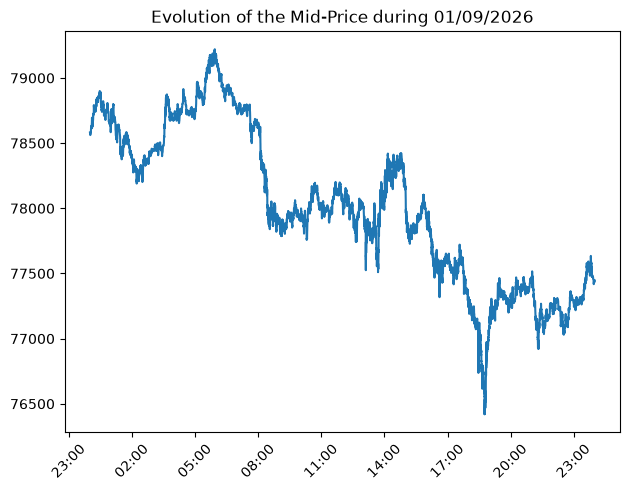

In [16]:
plt.plot(df_jump_price['datetime'], df_jump_price['mid_price'])

ax = plt.gca() #Get current axes

ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M')) #We only keep hours and minutes for the plot
ax.xaxis.set_major_locator(mdates.HourLocator(interval=3)) #every 3 hours

plt.xticks(rotation=45)
plt.tight_layout()

plt.title("Evolution of the Mid-Price during 01/09/2026")
plt.show()

In [50]:
df_jump_price = df_jump_price.copy()  

#We put +1/-1 if midprice increased/decreased
df_jump_price["sign_change"] = np.sign(
    df_jump_price["mid_price"] - df_jump_price["mid_price"].shift(1)
)


#We create the mid-price change column
df_jump_price["mid_price_change"]=df_jump_price["mid_price"] - df_jump_price["mid_price"].shift(1)


#Conditional mean according to the price change
mean_pos = df_jump_price.loc[
    df_jump_price["mid_price_change"] > 0,
    "mid_price_change"
].mean()

mean_neg= -df_jump_price.loc[
    df_jump_price["mid_price_change"] < 0,
    "mid_price_change"
].mean()

std_pos = df_jump_price.loc[
    df_jump_price["mid_price_change"] > 0,
    "mid_price_change"
].std()

std_neg= df_jump_price.loc[
    df_jump_price["mid_price_change"] < 0,
    "mid_price_change"
].std()

# ----------------------------------
rng = np.random.default_rng(seed=42)  # seed pour la reproductibilité

mask_pos = df_jump_price["sign_change"] == 1
mask_neg = df_jump_price["sign_change"] == -1

df_jump_price["sign_change_weighted"] = df_jump_price["sign_change"].astype(float).copy()

df_jump_price.loc[mask_pos, "sign_change_weighted"] = np.abs(
    rng.normal(loc=mean_pos, scale=std_pos, size=mask_pos.sum())
)
df_jump_price.loc[mask_neg, "sign_change_weighted"] = -np.abs(
    rng.normal(loc=mean_neg, scale=std_neg, size=mask_neg.sum())
)

df_jump_price["cumulative_weighted"] = df_jump_price["sign_change_weighted"].cumsum()


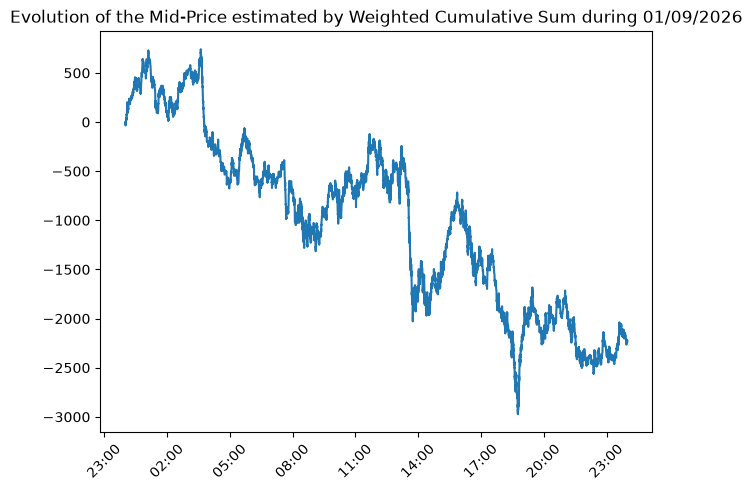

In [53]:
plt.plot(df_jump_price['datetime'], df_jump_price['cumulative_weighted'])


ax = plt.gca() #Get current axes

ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M')) #We only keep hours and minutes for the plot
ax.xaxis.set_major_locator(mdates.HourLocator(interval=3)) #every 3 hours

plt.xticks(rotation=45)
plt.tight_layout()

plt.title("Evolution of the Mid-Price estimated by Weighted Cumulative Sum during 01/09/2026")
plt.show()

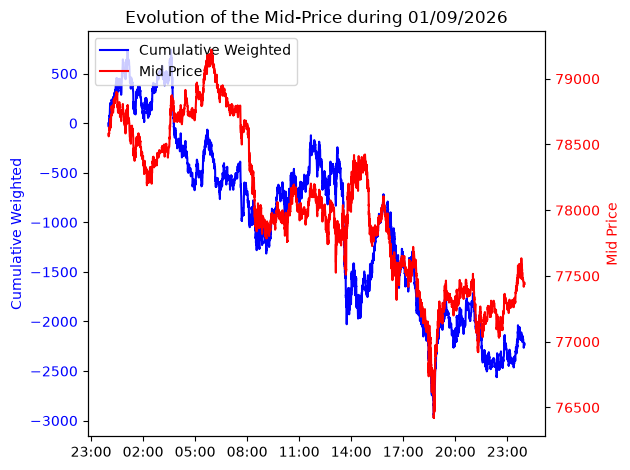

In [54]:

fig, ax1 = plt.subplots()

# 1st axis : cumulative weighted
line1, = ax1.plot(
    df_jump_price["datetime"],
    df_jump_price["cumulative_weighted"],
    color="blue",
    label="Cumulative Weighted"
)

ax1.set_ylabel("Cumulative Weighted", color="blue")
ax1.tick_params(axis="y", labelcolor="blue")


# 2nd axis : mid-price
ax2 = ax1.twinx()

line2, = ax2.plot(
    df_jump_price["datetime"],
    df_jump_price["mid_price"],
    color="red",
    label="Mid Price"
)

ax2.set_ylabel("Mid Price", color="red")
ax2.tick_params(axis="y", labelcolor="red")


# abscisse axis
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
ax1.xaxis.set_major_locator(mdates.HourLocator(interval=3))

plt.xticks(rotation=45)

# legend
ax1.legend(
    handles=[line1, line2],
    loc="upper left"
)

plt.title("Evolution of the Mid-Price during 01/09/2026")
plt.tight_layout()
plt.show()


In [6]:
import nest_asyncio
nest_asyncio.apply()

In [ ]:
from tardis_dev import download_datasets_async

await download_datasets_async(
    exchange="binance",
    data_types=["trades"],
    from_date="2026-09-01",
    to_date="2026-09-02",
    symbols=["BTCUSDT"],
    download_dir="./tardis_data",
)

In [ ]:
import glob, pandas as pd

files = glob.glob("./tardis_data/*.csv.gz")
print("Fichiers téléchargés :", files)

df = pd.read_csv(files[0])
print(df.columns.tolist())
df.head()

Fichiers téléchargés : ['/home/onyxia/work/binance_data_10_09/binance_trades_2026-09-01_BTCUSDT.csv.gz']
['exchange', 'symbol', 'timestamp', 'local_timestamp', 'id', 'side', 'price', 'amount']


,exchange,symbol,timestamp,local_timestamp,id,side,price,amount
0,binance,BTCUSDT,1788220800322740,1788220800348536,6642078844,buy,78581.30,0.00012
1,binance,BTCUSDT,1788220800491646,1788220800493229,6642078845,buy,78581.30,0.01700
2,binance,BTCUSDT,1788220800533037,1788220800535316,6642078846,buy,78581.30,0.00056
3,binance,BTCUSDT,1788220800697918,1788220800700300,6642078847,sell,78581.29,0.00071
4,binance,BTCUSDT,1788220800985433,1788220800989123,6642078848,sell,78581.29,0.00232


In [99]:
df_grouped = (
    df.assign(is_buy=(df['side'] == 'buy').astype(int))
      .groupby('timestamp', as_index=False)['is_buy']
      .mean()                                  # proportion of buy at this time_stamp
)
df_grouped['side'] = (df_grouped['is_buy'] >= 0.5).astype(int)
df_grouped = df_grouped.sort_values('timestamp').reset_index(drop=True)

t = df_grouped['timestamp'].to_numpy() / 1e6
t = t - t[0]
side = df_grouped['side'].to_numpy()

df_hawkes = pd.DataFrame({"time_stamp": t, "side": side})

dt = np.diff(t)
print("Δt =0  :", np.sum(dt == 0))  #should be 0

Δt =0  : 0


In [100]:
debut = 13 * 3600 # start at 1:00 pm   
fin = debut + 45 * 60    # 1:10 pm
mask = (t >= debut) & (t < fin) # [1pm, 1:10pm]

t_win = t[mask] - t[mask][0] 
side_win = side[mask]


df_hawkes = pd.DataFrame({
    "time_stamp": t_win,
    "side": side_win,
})

In [101]:
df_hawkes.count()

time_stamp    31871
side          31871
dtype: int64

In [103]:
T = t_win[-1] - t_win[0]
N1 = side_win.sum(); N2 = len(side_win) - N1
rate1, rate2 = N1 / T, N2 / T
dt_mean = np.mean(np.diff(t_win))

theta_init = np.array([
    rate1 * 0.3,           # mu1
    rate2 * 0.3,           # mu2
    0.3,                   # R11
    0.1,                   # R21
    0.1,                   # R12
    0.3,                   # R22
    1.0 / (5 * dt_mean),   # beta1
    1.0 / (5 * dt_mean),   # beta2
])

bounds = _default_bivariate_bounds()

constraints = [
                NonlinearConstraint(spectral_det, 1e-5, np.inf),
                NonlinearConstraint(trace_1, 1e-5, np.inf),
                NonlinearConstraint(trace_2, 1e-5, np.inf)
            ]

In [104]:
from Hawkes_functions import *

resultat = fit_bivariate(df_hawkes,
                  theta_init=np.array([0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.9, 0.9]),
                  method='SLSQP',
                  bounds=bounds,
                  constraints=None,
                  verbose=True)

Optimization terminated successfully    (Exit mode 0)
            Current function value: -86000.36709085401
            Iterations: 66
            Function evaluations: 725
            Gradient evaluations: 66

--- Bivariate : Estimated results ---
Succès de l'optimisation : True
Statut                   : Optimization terminated successfully

[Baseline intensity - mu]
mu1 (Dimension 1) : 2.937492
mu2 (Dimension 2) : 1.839758

[Branchement ratio matrix - R]
R11 (Auto-excitation 1->1)   : 0.5557
R21 (Croisée 1->2)           : 0.0010
R12 (Croisée 2->1)           : 0.0178
R22 (Auto-excitation 2->2)   : 0.6303

[beta]
beta1 (Chocs issus de 1) : 807.3172
beta2 (Chocs issus de 2) : 118.6979

[gamma]
-> gamma11 : 448.6160
-> gamma21 : 0.8351
-> gamma12 : 2.1088
-> gamma22 : 74.8205


In [105]:
theta_estimate=[resultat.x[i] for i in range(8)]

In [106]:
bivariate_goodness_of_fit(theta_estimate, df_hawkes, verbose=True)

--- Goodness of fit ---
KS Test       -> Stat: 0.0769 | p-value: 0.0000
Ljung-Box     -> Stat: 7768.0848 | p-value: 0.0000
empirical variance of résidus : 1.5699
Engle-Russell ED Test -> Stat Z: 27.3175 | p-value: 0.0000
KS Test       -> Stat: 0.0660 | p-value: 0.0000
Ljung-Box     -> Stat: 2575.3866 | p-value: 0.0000
empirical variance of résidus : 1.3115
Engle-Russell ED Test -> Stat Z: 12.7892 | p-value: 0.0000


((array([4.92653644, 1.22236207, 1.71393825, ..., 3.65651065, 3.64081166,
         1.55219712], shape=(18382,)),
  array([0.66750036, 0.72872543, 1.14120347, ..., 0.01485449, 1.7433802 ,
         0.72721121], shape=(13487,))),
 [(np.float64(5.9855801567853335e-95), np.float64(0.0), np.float64(0.0)),
  (np.float64(1.4592800567147326e-51), np.float64(0.0), np.float64(0.0))])

In [ ]:
windows = {}   # dict : hour -> df_hawkes for that time slot

duration = 45 * 60   # 45 min window (as in your example)

for h in range(24):                      # 0h to 23h
    start = h * 3600
    end = start + duration
    mask = (t >= start) & (t < end)

    # safety : skip empty or near-empty slots
    if mask.sum() < 2:
        continue

    t_win = t[mask] - t[mask][0]         # re-anchor the window to 0
    side_win = side[mask]

    windows[h] = pd.DataFrame({
        "time_stamp": t_win,
        "side": side_win,
    })